In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

print("Environment loaded.")
print("PyTorch:", torch.__version__)

Environment loaded.
PyTorch: 2.14.0+cpu


In [2]:
data_path = "../data/training.csv"

df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")

Dataset shape: (250000, 33)


In [3]:
feature_columns = [
    column
    for column in df.columns
    if column not in ["EventId", "Weight", "Label"]
]

X = df[feature_columns].replace(-999, np.nan)

y = (df["Label"] == "s").astype(int)

print("Number of features:", len(feature_columns))
print("Number of events:", len(X))
print("Signal fraction:", y.mean())

Number of features: 30
Number of events: 250000
Signal fraction: 0.342668


In [5]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Development set:", X_dev.shape)
print("Test set:", X_test.shape)

Development set: (200000, 30)
Test set: (50000, 30)


In [6]:
print("Development signal fraction:", y_dev.mean())
print("Test signal fraction:", y_test.mean())

Development signal fraction: 0.34267
Test signal fraction: 0.34266


In [7]:
logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42,
    )),
])

logistic_model.fit(X_dev, y_dev)

logistic_test_score = logistic_model.predict_proba(X_test)[:, 1]

logistic_test_auc = roc_auc_score(
    y_test,
    logistic_test_score,
)

print(f"Logistic regression test ROC-AUC: {logistic_test_auc:.4f}")

Logistic regression test ROC-AUC: 0.8123


In [8]:
tree_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=42,
)

tree_model.fit(X_dev, y_dev)

tree_test_score = tree_model.predict_proba(X_test)[:, 1]

tree_test_auc = roc_auc_score(
    y_test,
    tree_test_score,
)

print(f"Boosted-tree test ROC-AUC: {tree_test_auc:.4f}")

Boosted-tree test ROC-AUC: 0.9088


In [9]:
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_dev,
    y_dev,
    test_size=0.20,
    random_state=42,
    stratify=y_dev,
)

print("NN training:", X_train_nn.shape)
print("NN validation:", X_val_nn.shape)

NN training: (160000, 30)
NN validation: (40000, 30)


In [10]:
nn_imputer = SimpleImputer(strategy="median")
nn_scaler = StandardScaler()

X_train_nn_processed = nn_imputer.fit_transform(X_train_nn)
X_val_nn_processed = nn_imputer.transform(X_val_nn)
X_test_nn_processed = nn_imputer.transform(X_test)

X_train_nn_processed = nn_scaler.fit_transform(
    X_train_nn_processed
)

X_val_nn_processed = nn_scaler.transform(
    X_val_nn_processed
)

X_test_nn_processed = nn_scaler.transform(
    X_test_nn_processed
)

In [11]:
X_train_tensor = torch.tensor(
    X_train_nn_processed,
    dtype=torch.float32,
)

y_train_tensor = torch.tensor(
    y_train_nn.to_numpy(),
    dtype=torch.float32,
).reshape(-1, 1)

X_val_tensor = torch.tensor(
    X_val_nn_processed,
    dtype=torch.float32,
)

y_val_tensor = torch.tensor(
    y_val_nn.to_numpy(),
    dtype=torch.float32,
).reshape(-1, 1)

X_test_tensor = torch.tensor(
    X_test_nn_processed,
    dtype=torch.float32,
)

y_test_tensor = torch.tensor(
    y_test.to_numpy(),
    dtype=torch.float32,
).reshape(-1, 1)

In [12]:
class HiggsNetwork(nn.Module):

    def __init__(self, n_features):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x)

In [13]:
nn_model = HiggsNetwork(
    n_features=X_train_tensor.shape[1]
)

print(nn_model)

HiggsNetwork(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [14]:
loss_function = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    nn_model.parameters(),
    lr=0.001,
)

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=True,
)

In [15]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    loss_function,
):
    model.train()

    total_loss = 0.0

    for X_batch, y_batch in loader:

        optimizer.zero_grad()

        logits = model(X_batch)

        loss = loss_function(
            logits,
            y_batch,
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(X_batch)

    return total_loss / len(loader.dataset)

In [16]:
nn_loss_history = []

for epoch in range(10):

    loss = train_one_epoch(
        nn_model,
        train_loader,
        optimizer,
        loss_function,
    )

    nn_loss_history.append(loss)

    print(
        f"Epoch {epoch + 1:2d} | "
        f"loss = {loss:.4f}"
    )

Epoch  1 | loss = 0.4978
Epoch  2 | loss = 0.3965
Epoch  3 | loss = 0.3811
Epoch  4 | loss = 0.3748
Epoch  5 | loss = 0.3705
Epoch  6 | loss = 0.3674
Epoch  7 | loss = 0.3649
Epoch  8 | loss = 0.3630
Epoch  9 | loss = 0.3612
Epoch 10 | loss = 0.3597


In [17]:
def predict_probability(model, X):

    model.eval()

    with torch.no_grad():
        logits = model(X)
        probabilities = torch.sigmoid(logits)

    return probabilities.numpy().ravel()

In [18]:
nn_test_score = predict_probability(
    nn_model,
    X_test_tensor,
)

nn_test_auc = roc_auc_score(
    y_test,
    nn_test_score,
)

print(f"Neural network test ROC-AUC: {nn_test_auc:.4f}")

Neural network test ROC-AUC: 0.9055


In [19]:
results = pd.DataFrame({
    "Model": [
        "Logistic regression",
        "Gradient-boosted trees",
        "Neural network",
    ],
    "Test ROC-AUC": [
        logistic_test_auc,
        tree_test_auc,
        nn_test_auc,
    ],
})

results

,Model,Test ROC-AUC
0,Logistic regression,0.812336
1,Gradient-boosted trees,0.908759
2,Neural network,0.905502


In [20]:
logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_test_score,
)

tree_fpr, tree_tpr, _ = roc_curve(
    y_test,
    tree_test_score,
)

nn_fpr, nn_tpr, _ = roc_curve(
    y_test,
    nn_test_score,
)

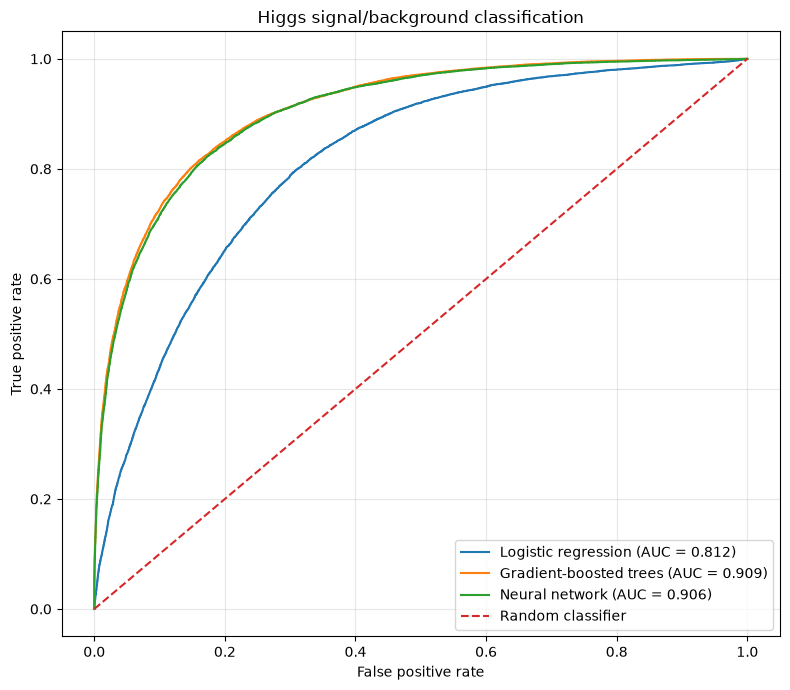

In [22]:
plt.figure(figsize=(8, 7))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic regression (AUC = {logistic_test_auc:.3f})",
)

plt.plot(
    tree_fpr,
    tree_tpr,
    label=f"Gradient-boosted trees (AUC = {tree_test_auc:.3f})",
)

plt.plot(
    nn_fpr,
    nn_tpr,
    label=f"Neural network (AUC = {nn_test_auc:.3f})",
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random classifier",
)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Higgs signal/background classification")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../figures/final_roc_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Final evaluation

Three classifiers were trained for the Higgs signal/background
classification problem:

1. Logistic regression
2. Gradient-boosted decision trees
3. A small fully connected neural network

The models were trained using the development dataset and evaluated
on an independent test set that was not used during model selection.

The final comparison is based on ROC-AUC.

In [23]:
results.sort_values(
    "Test ROC-AUC",
    ascending=False,
)

,Model,Test ROC-AUC
1,Gradient-boosted trees,0.908759
2,Neural network,0.905502
0,Logistic regression,0.812336
